In [67]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from datetime import datetime, timedelta
import seaborn as sns
import shapely

In [68]:
def parse_gpx(gpx_file):
    gdf = gpd.read_file(gpx_file, layer="track_points")
    gdf = gdf[["time", "ele", "geometry"]]
    gdf["time"] = pd.to_datetime(gdf["time"])
    gdf = gdf.rename(columns={"time": "datetime", "ele": "elevation"})
    gdf["elapsed_time"] = gdf["datetime"].diff().cumsum()
    gdf["elapsed_time"] = gdf["elapsed_time"].fillna(timedelta(seconds=0))
    gdf["elapsed_distance (mi)"] = (
        gdf.to_crs(gdf.estimate_utm_crs())["geometry"]
        .distance(gdf.to_crs(gdf.estimate_utm_crs())["geometry"].shift())
        .cumsum()
        / 1609
    )
    gdf["elapsed_distance (mi)"] = gdf["elapsed_distance (mi)"].fillna(0)
    gdf["pace (min/mi)"] = (gdf["elapsed_time"].dt.total_seconds() / 60).diff(10) / gdf[
        "elapsed_distance (mi)"
    ].diff(10)
    gdf["pace (min/mi)"] = gdf["pace (min/mi)"].bfill()
    return gdf[
        [
            "datetime",
            "elapsed_time",
            "elapsed_distance (mi)",
            "pace (min/mi)",
            "elevation",
            "geometry",
        ]
    ]

In [69]:
file = '/Users/ryansponzilli/Developer/Python Projects/health-data/data/raw/apple_health/apple_health_export/workout-routes/route_2022-09-08_4.24pm.gpx'
gpd.list_layers(file)

,name,geometry_type
0,waypoints,Point
1,routes,LineString
2,tracks,MultiLineString
3,route_points,Point
4,track_points,Point


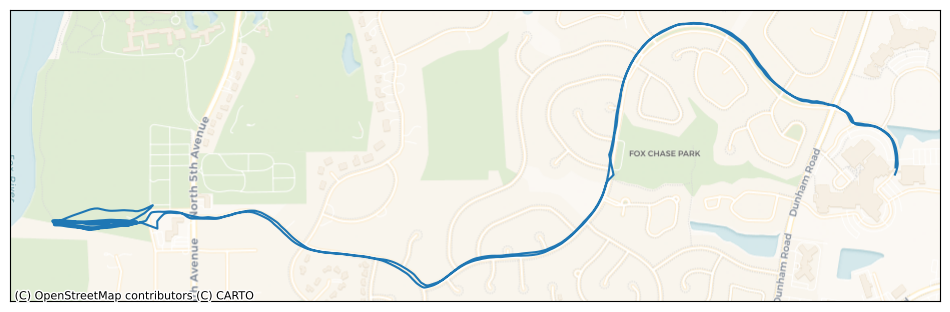

In [81]:
fig, ax = plt.subplots(figsize=(12, 5))
gpd.read_file(file, layer="tracks").to_crs(3857).plot(ax=ax)
cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)
ax.tick_params(bottom=False, top=False, left=False, right=False, labelbottom=False, labeltop=False, labelleft=False, labelright=False)

In [70]:
gdf = parse_gpx(file)
gdf

,datetime,elapsed_time,elapsed_distance (mi),pace (min/mi),elevation,geometry
0,2022-09-08 20:08:17+00:00,0 days 00:00:00,0.000000,10.906421,232.041046,POINT (-88.27981 41.92868)
1,2022-09-08 20:08:18+00:00,0 days 00:00:01,0.000486,10.906421,232.037796,POINT (-88.27981 41.92869)
2,2022-09-08 20:08:19+00:00,0 days 00:00:02,0.002490,10.906421,232.029541,POINT (-88.27981 41.92872)
3,2022-09-08 20:08:20+00:00,0 days 00:00:03,0.004492,10.906421,232.023087,POINT (-88.27981 41.92875)
4,2022-09-08 20:08:21+00:00,0 days 00:00:04,0.006218,10.906421,232.015594,POINT (-88.27981 41.92877)
...,...,...,...,...,...,...
2788,2022-09-08 21:24:53+00:00,0 days 01:16:36,6.411210,8.281158,231.708603,POINT (-88.2798 41.92856)
2789,2022-09-08 21:24:54+00:00,0 days 01:16:37,6.413144,8.337945,231.746201,POINT (-88.27981 41.92854)
2790,2022-09-08 21:24:55+00:00,0 days 01:16:38,6.415078,8.370609,231.785324,POINT (-88.27982 41.92851)
2791,2022-09-08 21:24:56+00:00,0 days 01:16:39,6.417076,8.407856,231.825195,POINT (-88.27984 41.92848)


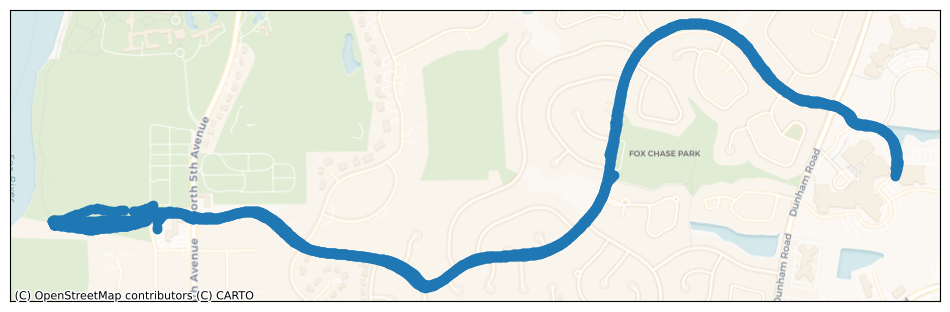

In [80]:
fig, ax = plt.subplots(figsize=(12, 5))

gdf.to_crs(3857).plot(ax=ax)
cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)
ax.tick_params(bottom=False, top=False, left=False, right=False, labelbottom=False, labeltop=False, labelleft=False, labelright=False)